Time to switch things up! The Titanic dataset has been explored countless times, so I decided to take a fresh approach and build a new notebook using the Penguins dataset from the Seaborn package. Who doesn't love the thought of a sweet Penguin? :)

For the best viewing experience, please paste this notebook’s GitHub link into https://nbviewer.org
Hope you enjoy!

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
Penguins = sns.load_dataset("penguins")
Penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
Penguins.shape

(344, 7)

There are 344 rows of data and 7 columns.

In [4]:
import missingno as msno

<Axes: >

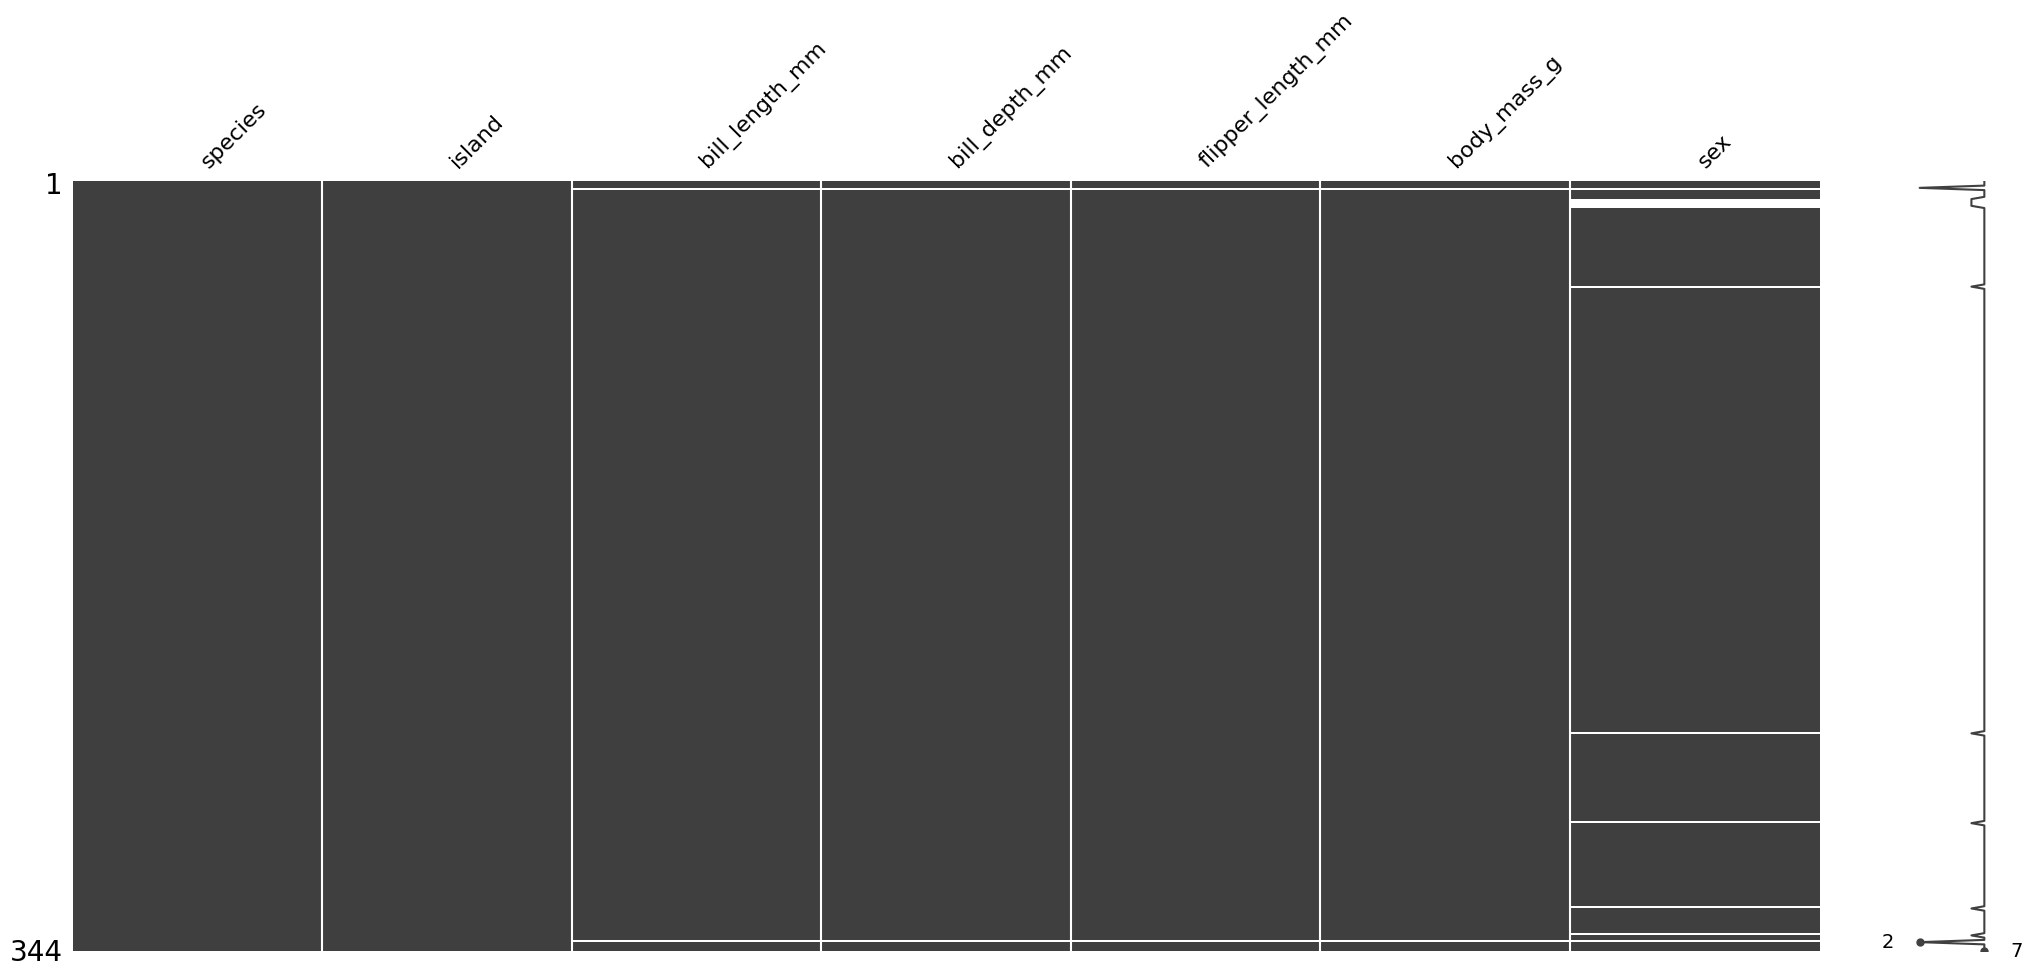

In [5]:
msno.matrix(Penguins)

In [6]:
Penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

This confirms that the data missing values is within the best practice guidlines (<5%) so we will drop these values to continue with analysis.

In [7]:
Penguins.dropna(inplace=True)

In [8]:
Penguins.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 26.7 KB


We now have 333 rows of data. 

In [9]:
import matplotlib.pyplot as plt

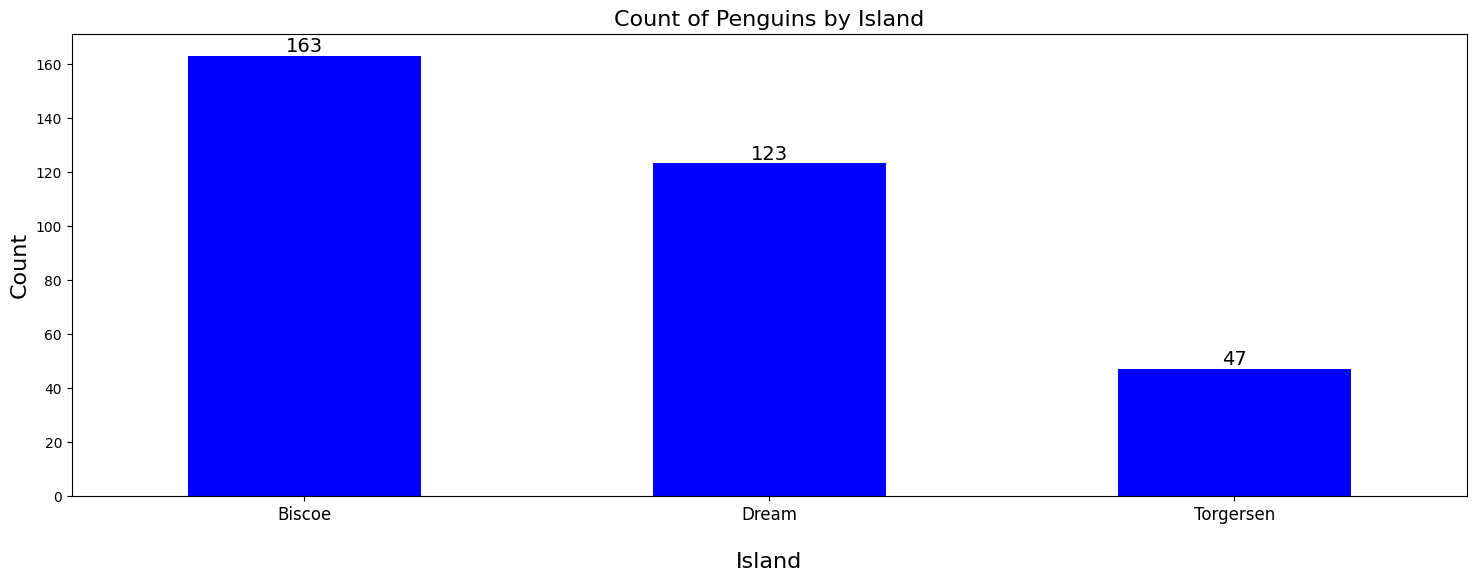

In [11]:
# Visualizing the Penguins by Island! 
ax = Penguins['island'].value_counts().plot(kind='bar', figsize=(18,6), color='blue')
#Labeling the values on top of each bar. 
for container in ax.containers:
    ax.bar_label(container, fontsize=14)
#Increasing the size of the labels and using rotation=0 to have each island name horozontal without rotation. Makes labels easier to read.
ax.tick_params(axis='x', rotation=0, labelsize=12)
#Creating space between the x axis and the label using labelpad=20 to make this more aestetically pleasing.
ax.set_title("Count of Penguins by Island", fontsize=16)
ax.set_xlabel("Island", fontsize=16, labelpad=20)
ax.set_ylabel("Count", fontsize=16)

plt.show()

Biscoe Island has the most Penguins, followed by Dream, and lastly Torgersen.

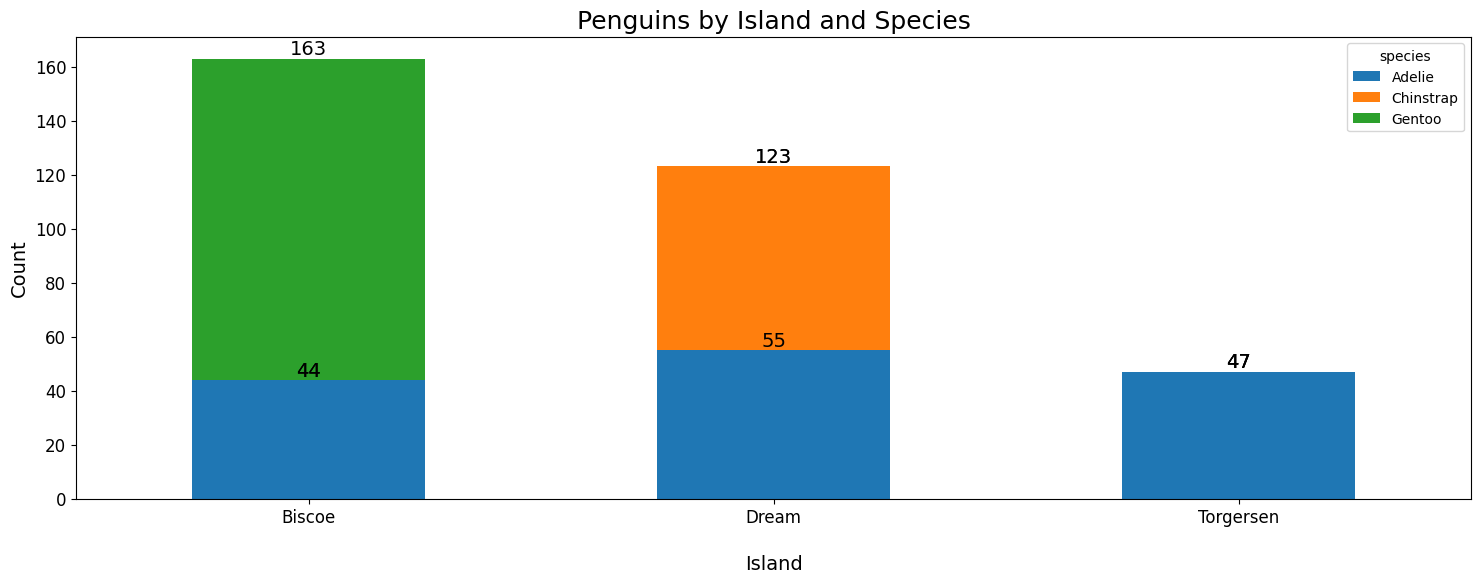

In [12]:
# Now adding in the species to view as a stacked bar chart!
StackedBarChart = Penguins.groupby(['island', 'species']).size().unstack()

ax = StackedBarChart.plot(kind='bar', stacked=True, figsize=(18,6))
for container in ax.containers:
    ax.bar_label(container, fontsize=14)
ax.tick_params(axis='x', rotation=0, labelsize=12)
ax.set_title("Penguins by Island and Species", fontsize=18)
ax.set_xlabel("Island", fontsize=14, labelpad=20)
ax.set_ylabel("Count", fontsize=14)

ax.tick_params(axis='both', labelsize=12)

plt.show()

Before we go any further, here are some beautiful images of the three species of penguin from this website on the Australian Antartic Program: https://www.antarctica.gov.au/about-antarctica/animals/penguins/gentoo-penguin/#:~:text=Gentoo%20penguins%20are%20closely%20related,have%20a%20large%20geographic%20range.

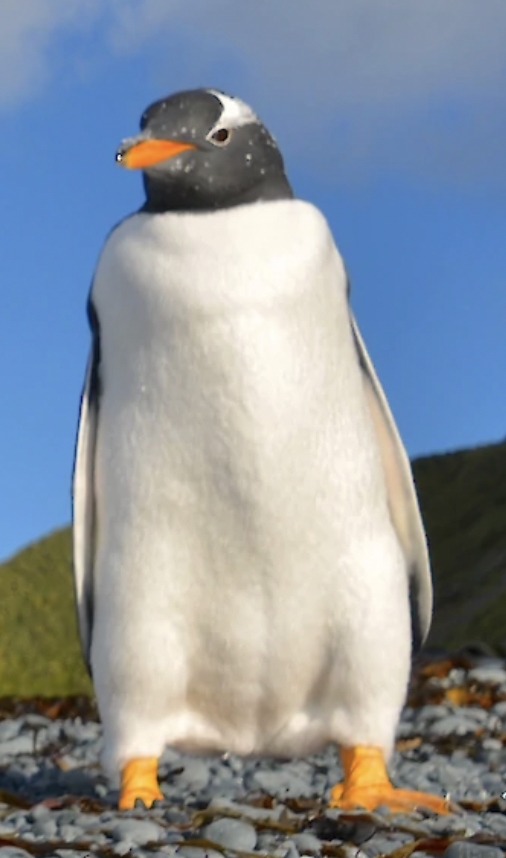

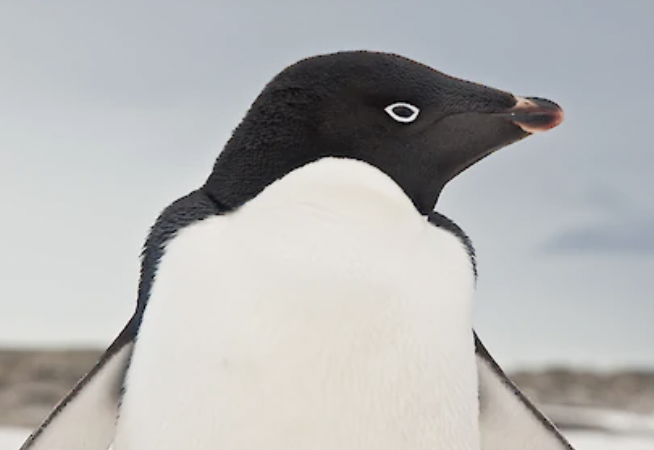

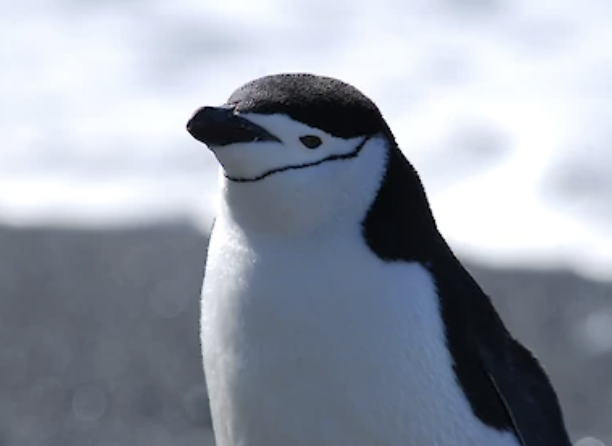

In [13]:
from IPython.display import Image, display

display(Image(filename="MediaImages/Gentoo.png", width=300))
display(Image(filename="MediaImages/Adelie.png", width=300))
display(Image(filename="MediaImages/Chinstrap.png", width=300))

Above you can see how incredibly adorable all three species are! From the top, we have the Gentoo Penguin, next the Adelie Penguin, & last but not least the adorable Chinstrap Penguin! 

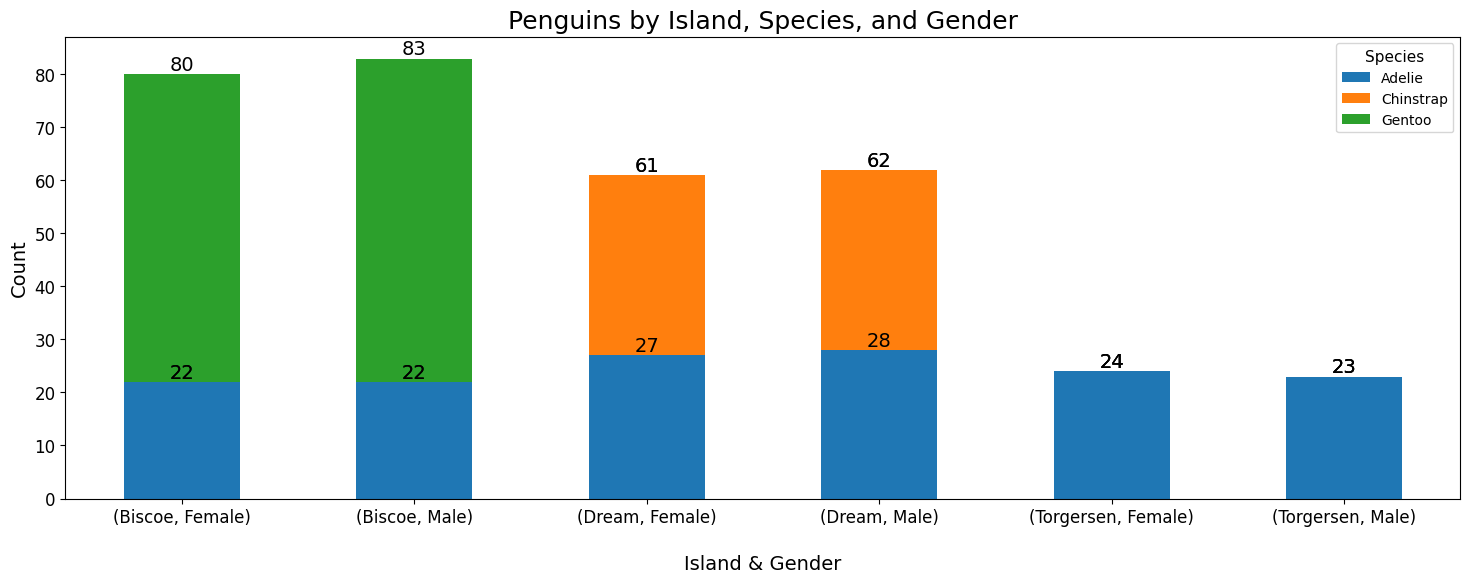

In [14]:
# Now let's add in gender to see if there are significant differences based on gender.
Data = Penguins.groupby(['island', 'sex', 'species']).size().unstack()

ax = Data.plot(kind='bar', stacked=True, figsize=(18,6))
for container in ax.containers:
    ax.bar_label(container, fontsize=14)

ax.tick_params(axis='x', rotation=0, labelsize=12)
ax.set_title("Penguins by Island, Species, and Gender", fontsize=18)
ax.set_xlabel("Island & Gender", fontsize=14, labelpad=20)
ax.set_ylabel("Count", fontsize=14)

ax.tick_params(axis='both', labelsize=12)
ax.legend(title="Species", fontsize=10, title_fontsize=11)
plt.show()

Gender is very even amongst the Species and Island. And we can see the values above each bar in the stacked bar chart making this visualization very easy to read.

Before we do more analysis below, I would like to share some visualizations I made on Tableau with this data.

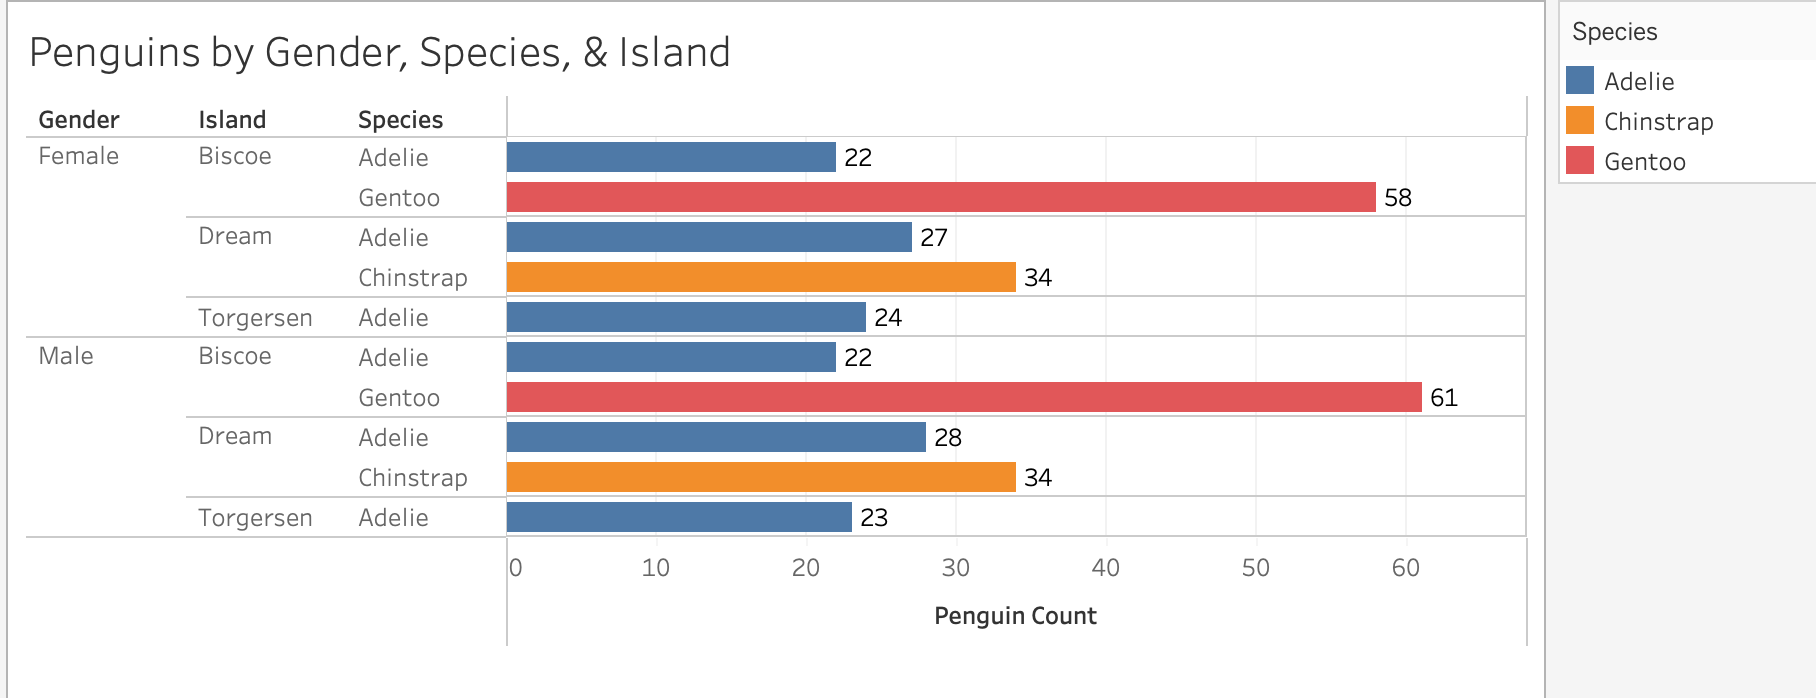

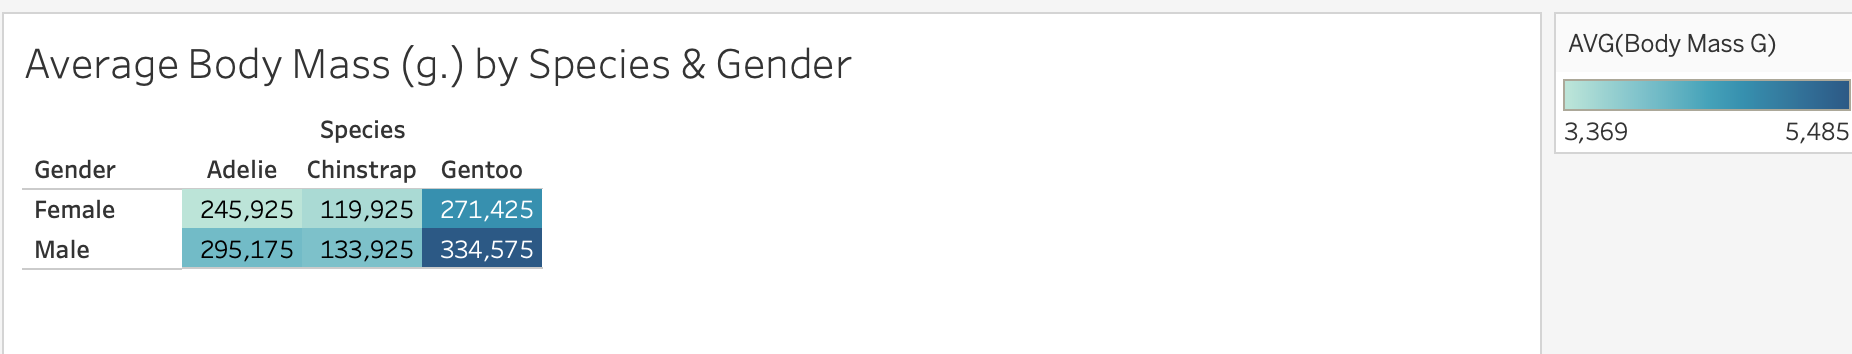

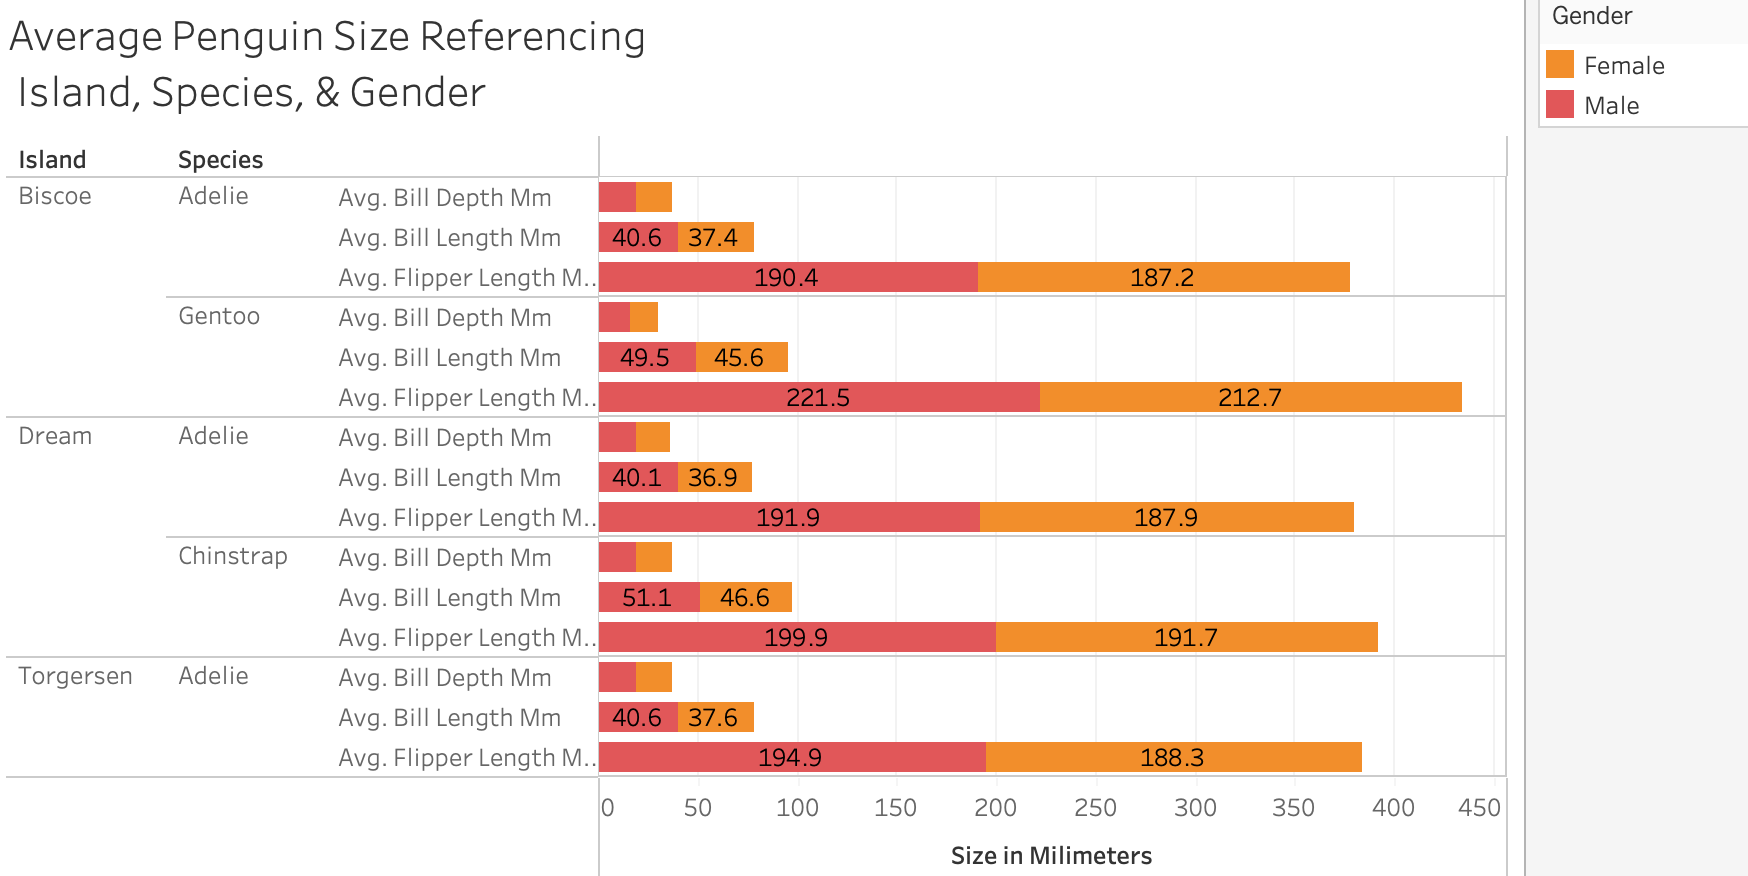

In [15]:
display(Image(filename="MediaImages/Penguins1.png", width=900))
display(Image(filename="MediaImages/Penguins2.png", width=900))
display(Image(filename="MediaImages/Penguins3.png", width=900))

In [16]:
from skimpy import skim

In [17]:
skim(Penguins)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 333    │ │ float64     │ 4     │                                                          │
│ │ Number of columns │ 7      │ │ string      │ 3     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column                ┃ NA  ┃ NA %   ┃ mean    ┃ sd      ┃ p0    ┃ p25   ┃ p50   ┃ p75   ┃ p100  ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━┩  │
│ │    bill_length_mm     │   0 │      0 │   43.99 │   5.469 │  32.1 │  39.5 │  44.5 │  48.6 │  59.6 │  ▃█▆█▃  │  │
│ │     bill_depth_mm     │   0 │      0 │   17.16 │   1.969 │  13.1 │  15.6 │  17.3 │  18.7 │  21.5 │ ▃▅▆█▆▁  │  │
│ │   flipper_length_mm   │   0 │      0 │     201 │   14.02 │   172 │   190 │   197 │   213 │   231 │ ▂██▄▆▃  │  │
│ │      body_mass_g      │   0 │      0 │    4207 │   805.2 │  2700 │  3550 │  4050 │  4775 │  6300 │ ▂█▆▄▃▁  │  │
│ └───────────────────────┴─────┴────────┴─────────┴─────────┴───────┴───────┴───────┴───────┴───────┴─────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃         ┃    ┃      ┃          ┃           ┃        ┃           ┃ chars per   ┃ words per    ┃             ┃  │
│ ┃ column  ┃ NA ┃ NA % ┃ shortest ┃ longest   ┃ min    ┃ max       ┃ row         ┃ row          ┃ total words ┃  │
│ ┡━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ species │  0 │    0 │  Adelie  │  Adelie   │ Adelie │  Gentoo   │        6.61 │            1 │         333 │  │
│ │ island  │  0 │    0 │  Biscoe  │ Torgersen │ Biscoe │ Torgersen │        6.05 │            1 │         333 │  │
│ │   sex   │  0 │    0 │   Male   │  Female   │ Female │   Male    │        4.99 │            1 │         333 │  │
│ └─────────┴────┴──────┴──────────┴───────────┴────────┴───────────┴─────────────┴──────────────┴─────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

I absolutely love this skim function from skimpy and all the information it provides us in this beautiful table! This table provides a great overview of an analysis of our variables including descriptive statistics.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
%matplotlib inline
from sklearn.model_selection import train_test_split

In [19]:
Penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [20]:
# I like having the columns capitalized.
Penguins.columns = Penguins.columns.str.capitalize()

In [21]:
Penguins.head()

,Species,Island,Bill_length_mm,Bill_depth_mm,Flipper_length_mm,Body_mass_g,Sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


<Axes: xlabel='Sex', ylabel='Species'>

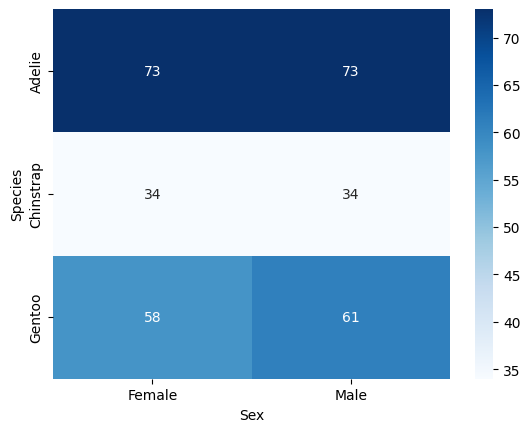

In [22]:
HeatMap = pd.crosstab(Penguins["Species"], Penguins["Sex"])
sns.heatmap(HeatMap, annot=True, cmap="Blues")

The Gender is very even for each species.

In [23]:
pd.crosstab(Penguins["Species"], Penguins["Sex"])

Sex,Female,Male
Species,,
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [25]:
y = Penguins["Species"]

In [26]:
print(Penguins.columns.tolist())

['Species', 'Island', 'Bill_length_mm', 'Bill_depth_mm', 'Flipper_length_mm', 'Body_mass_g', 'Sex']


Building a pipeline that will pre-process the data and then fit it in Logistic Regression:

In [27]:
# These are our numeric and categorical features being defined for our pipeline below.
Numeric_features = ["Bill_length_mm", "Bill_depth_mm", "Flipper_length_mm", "Body_mass_g"]
Categorical_features = ["Island", "Sex"]

In [28]:
Numeric_Transforming = Pipeline(steps=[("scaler", StandardScaler())])
Categorical_Transforming = Pipeline(steps=[("encoder", OneHotEncoder(handle_unknown="ignore"))])

In [29]:
# Transforming our data numerically and categorically
Pre_Processor = ColumnTransformer(
    transformers=[
        ("num", Numeric_Transforming, Numeric_features),
        ("cat", Categorical_Transforming, Categorical_features)
    ])

In [30]:
# Passing the Model through Logistic Regression
Model = Pipeline(steps=[
    ("Pre_Processor", Pre_Processor),
    ("Classifier", LogisticRegression(max_iter=10000))
])

In [31]:
X = Penguins.drop("Species", axis=1)
y = Penguins["Species"]

In [32]:
# Making sure our output is the same number of rows for our analysis
print(len(X))
print(len(y))

333
333


In [33]:
from sklearn.model_selection import train_test_split

In [34]:
# Training our Model, using 20% of the data for testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Pre_Processor', ...), ('Classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [35]:
from sklearn.metrics import classification_report, accuracy_score

In [36]:
y_pred = Model.predict(X_test)

In [37]:
score = accuracy_score(y_test, y_pred)
result = (score * 100)
print(result)

98.50746268656717


The model’s accuracy score of 98.5% may appear unusually high, but this is typical for the penguins dataset. The species exhibit physical differences, especially in overall size, which contributes to strong model performance.

In [38]:
print("Accuracy of Logistic Regression:", result, '\n')
print(classification_report(y_test, y_pred))

Accuracy of Logistic Regression: 98.50746268656717 

              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

Text(0.5, 1.0, 'Confusion Matrix')

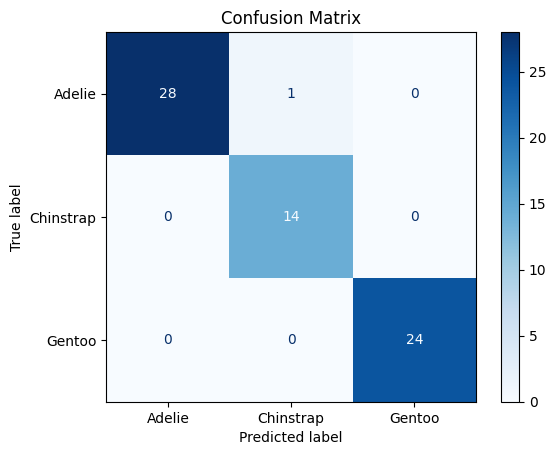

In [40]:
Show = ConfusionMatrixDisplay.from_estimator(
    Model, 
    X_test, 
    y_test,
    cmap="Blues",
    values_format="d"
)

Show.ax_.set_title("Confusion Matrix")

I love the color and how easy the confusion matrix makes the data visually displayed. The left to right diagonal show all the correct predictions for the category. The other cells represent incorrect predictions. The very top row shows 28 were correctly predicted as Adele Penguins, the next cell shows one incorrectly predicted a Chinstrap Peguin, and the cell on the top right shows zero were incorrectly predicated as Gentoo Penguins. The next row show 0 incorrectly predicted as Adele, next cell show 14 correctly predicted as Chinstrap, and the next cell show zero incorrectly predicted as Gentoo. Finally, the last row shows zero incorrectly predicted for both Adele and then Chinstrap Penguins, while at the bottom right showing 24 correctly predicated as Gentoo Penguins. 

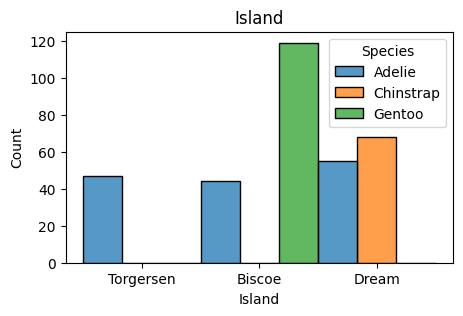

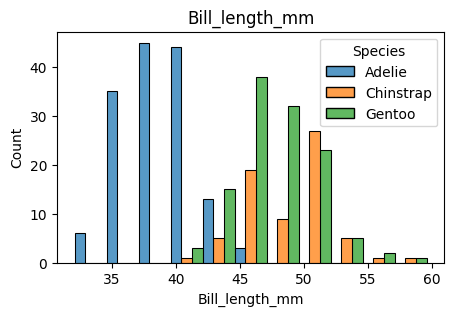

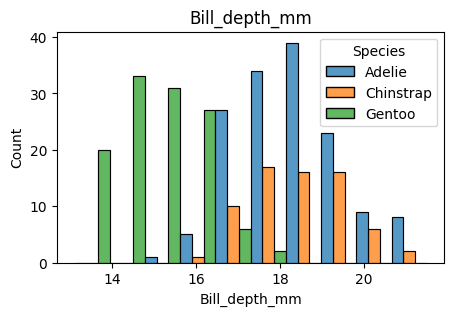

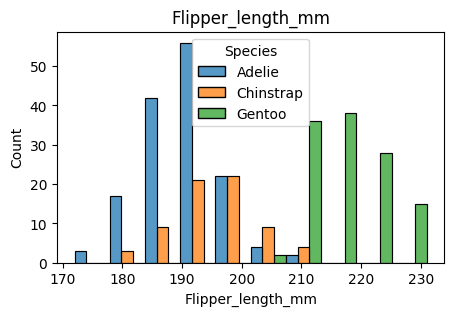

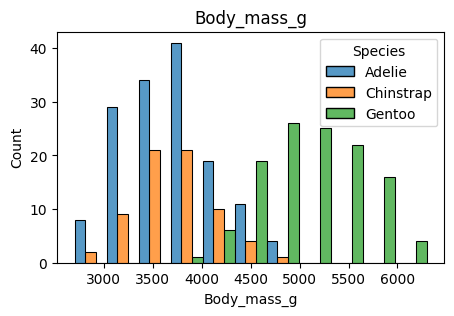

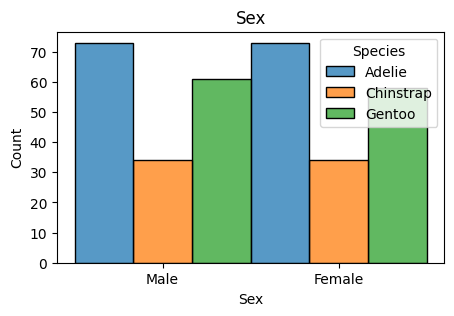

In [41]:
# LOVE these plots, absolutely gorgeous!
for ex in X:
    plt.figure(figsize=(5, 3))
    sns.histplot(data=Penguins, x=ex, hue="Species", kde=False, multiple="dodge")
    plt.title(ex)
#kde= False, makes nice bars, multiple ="dodge" keeps the bars nice and clean side by side

Random Forest:

In [42]:
RF = Pipeline(steps=[
    ("Pre_Processor", Pre_Processor),
    ("Model", RandomForestClassifier(n_estimators=100, random_state=42))
])

RF.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Pre_Processor', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [43]:
RF_y_pred = RF.predict(X_test)

In [44]:
accuracy_score(y_test, RF_y_pred)

1.0

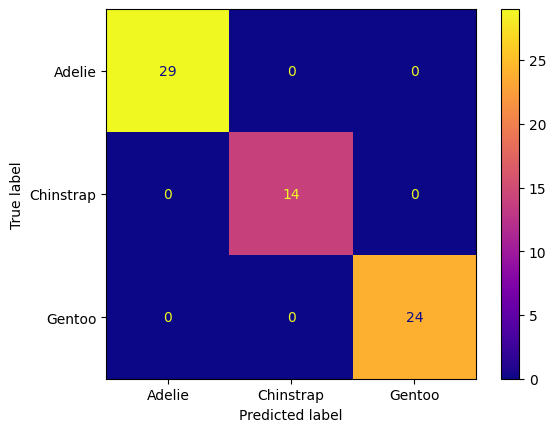

In [45]:
PS = RF.predict(X_test)
CM=confusion_matrix(y_test, PS, labels=RF.classes_)
DISP=ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=RF.classes_)
DISP.plot(cmap=plt.cm.plasma)
plt.show()

Hope you enjoyed! 

I would like to give credit & thanks to Copilot for assisting me in reviewing code for this notebook. I would also like to give credit & thanks for Amandeep Sawhney's Udemy course that has inspired me in creating the Tableau visualizations.